In [1]:
# =========================
# STEP 1: Import Libraries
# =========================

import os
import cv2
import random
import shutil
import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint



In [2]:
#define paths and create folders 

import os

PROCESSED_DIR = os.path.join(os.getcwd(), "processed_dataset")
TRAIN_DIR = os.path.join(PROCESSED_DIR, "train")
VAL_DIR   = os.path.join(PROCESSED_DIR, "val")
TEST_DIR  = os.path.join(PROCESSED_DIR, "test")

CLASSES = ["raw", "semi_cooked", "fully_cooked"]

for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in CLASSES:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

print(" processed_dataset folders created")  

 processed_dataset folders created


In [3]:
import cv2
import os
import random
import shutil

DATASET_DIR = os.path.join(os.getcwd(), "dataset")
NOISELESS_DIR = os.path.join(os.getcwd(), "processed_noiseless")  # store noise removed images

#Noise removal and store in noiseless folder
os.makedirs(NOISELESS_DIR, exist_ok=True)
for cls in CLASSES:
    src_class_path = os.path.join(DATASET_DIR, cls)
    dest_class_path = os.path.join(NOISELESS_DIR, cls)
    os.makedirs(dest_class_path, exist_ok=True)

    for img_name in os.listdir(src_class_path):
        img_path = os.path.join(src_class_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Remove noise
        img = cv2.GaussianBlur(img, (5,5), 0)

        # Save noise-removed image
        cv2.imwrite(os.path.join(dest_class_path, img_name), img)

print("Noise removal completed. Images stored in 'processed_noiseless/'.")

# Split noiseless images into train/val/test
train_ratio = 0.7
val_ratio = 0.15
for cls in CLASSES:
    class_path = os.path.join(NOISELESS_DIR, cls)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_imgs = images[:train_end]
    val_imgs   = images[train_end:val_end]
    test_imgs  = images[val_end:]

    for img_set, split_dir in zip([train_imgs, val_imgs, test_imgs],
                                  [TRAIN_DIR, VAL_DIR, TEST_DIR]):
        for img_name in img_set:
            src_path = os.path.join(class_path, img_name)
            dst_path = os.path.join(split_dir, cls, img_name)
            shutil.copy2(src_path, dst_path)  # copy to train/val/test

print("Data split into train/val/test completed.")



Noise removal completed. Images stored in 'processed_noiseless/'.
Data split into train/val/test completed.


In [4]:
# all the images all looking similar before and after noise removal so check whether there is any difference or nor we will do this
import cv2
import numpy as np
import os
orig_path = "dataset/raw/raw_1.jpg"
noisy_path = "processed_noiseless/raw/raw_1.jpg"

orig = cv2.imread(orig_path)
noisy = cv2.imread(noisy_path)

if orig is None or noisy is None:
    raise ValueError("Image not loaded. Check path or filename.")
else:
    diff = cv2.absdiff(orig, noisy)
    print("✅ Mean pixel difference:", np.mean(diff))



✅ Mean pixel difference: 1.0333452224731445


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import numpy as np
import os

AUG_PER_IMAGE = 3

datagen = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.02,
    height_shift_range=0.02,
    horizontal_flip=False,
    fill_mode='nearest',
    cval=0
)

for cls in CLASSES:
    class_dir = os.path.join(TRAIN_DIR, cls)
    images = [img for img in os.listdir(class_dir)
              if img.lower().endswith(('.jpg', '.png', '.jpeg'))
              and not img.startswith("aug")]

    print(f"\nClass: {cls}, original images: {len(images)}")

    aug_count = 0

    for img_name in images:
        img_path = os.path.join(class_dir, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = np.expand_dims(img, axis=0)

        aug_iter = datagen.flow(img, batch_size=1)

        for k in range(AUG_PER_IMAGE):
            aug_img = next(aug_iter)[0].astype(np.uint8)

            aug_filename = f"aug_{os.path.splitext(img_name)[0]}_{k}.jpg"
            save_path = os.path.join(class_dir, aug_filename)

            cv2.imwrite(save_path, aug_img)
            aug_count += 1

    total_images = len(os.listdir(class_dir))
    print(f"Augmented images created: {aug_count}")
    print(f"Final images in {cls}: {total_images}")



Class: raw, original images: 105
Augmented images created: 315
Final images in raw: 420

Class: semi_cooked, original images: 105
Augmented images created: 315
Final images in semi_cooked: 420

Class: fully_cooked, original images: 105
Augmented images created: 315
Final images in fully_cooked: 420


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training data (augmentation + normalization)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Validation & Test data (ONLY normalization)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 1260 images belonging to 3 classes.
Found 66 images belonging to 3 classes.
Found 69 images belonging to 3 classes.


In [7]:
#==================
#Load ResNet Model
#==================

NUM_CLASSES = 3  # raw, semi_cooked, fully_cooked

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)
#==============
#Model Compile
#==============
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
#=================
#Call backs
#=================
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        "resnet_rice_model.h5",
        monitor="val_accuracy",
        save_best_only=True
    )
]


In [9]:
#train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)


c:\Users\ruhin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3900 - loss: 1.4438

40/40 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.3925 - loss: 1.4359 - val_accuracy: 0.8485 - val_loss: 0.6154 - learning_rate: 1.0000e-04
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7455 - loss: 0.6296

40/40 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.7463 - loss: 0.6282 - val_accuracy: 0.8788 - val_loss: 0.4307 - learning_rate: 1.0000e-04
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8346 - loss: 0.4463

40/40 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.8352 - loss: 0.4456 - val_accuracy: 0.9242 - val_loss: 0.3207 - learning_rate: 1.0000e-04
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8870 - loss: 0.3357

40/40 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.8872 - loss: 0.3353 - val_accuracy: 0.9545 - val_loss: 0.2655 - learning_rate: 1.0000e-04
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.9160 - loss: 0.2970 - val_accuracy: 0.9242 - val_loss: 0.2347 - learning_rate: 1.0000e-04
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.9347 - loss: 0.2367 - val_accuracy: 0.9394 - val_loss: 0.2049 - learning_rate: 1.0000e-04
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.9461 - loss: 0.1956 - val_accuracy: 0.9545 - val_loss: 0.1917 - learning_rate: 1.0000e-04
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.9499 - loss: 0.1783 - val_accuracy: 0.9394 - val_loss: 0.1677 - learning_rate: 1.0000e-04
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.9453 - loss: 0.1730 - val_accuracy: 0.9242 - val_loss: 0.1705 - learning_rate: 1.0000e-04
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.9635 - loss: 0.

40/40 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.9633 - loss: 0.1406 - val_accuracy: 0.9697 - val_loss: 0.1501 - learning_rate: 1.0000e-04
Epoch 12/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.9690 - loss: 0.1246 - val_accuracy: 0.9545 - val_loss: 0.1413 - learning_rate: 1.0000e-04
Epoch 13/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.9762 - loss: 0.1116 - val_accuracy: 0.9394 - val_loss: 0.1402 - learning_rate: 1.0000e-04
Epoch 14/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.9744 - loss: 0.0960 - val_accuracy: 0.9545 - val_loss: 0.1303 - learning_rate: 1.0000e-04
Epoch 15/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.9803 - loss: 0.0883 - val_accuracy: 0.9545 - val_loss: 0.1235 - learning_rate: 1.0000e-04
Epoch 16/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.9662 - loss: 0.1003 - val_accuracy: 0.9697 - val_loss: 0.1270 - learning_rate: 1.0000e-04
Epoch 17/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.9741 - los

In [10]:
#Fine Tuning
# Unfreeze top ResNet layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 215s 5s/step - accuracy: 0.9411 - loss: 0.1682 - val_accuracy: 0.9697 - val_loss: 0.1721 - learning_rate: 1.0000e-05
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 172s 4s/step - accuracy: 0.9886 - loss: 0.0436 - val_accuracy: 0.9091 - val_loss: 0.2084 - learning_rate: 1.0000e-05
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 169s 4s/step - accuracy: 0.9978 - loss: 0.0219 - val_accuracy: 0.9394 - val_loss: 0.2001 - learning_rate: 1.0000e-05
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 460s 12s/step - accuracy: 0.9982 - loss: 0.0121 - val_accuracy: 0.9394 - val_loss: 0.1736 - learning_rate: 1.0000e-05
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 176s 4s/step - accuracy: 0.9998 - loss: 0.0072 - val_accuracy: 0.9697 - val_loss: 0.1502 - learning_rate: 3.0000e-06
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 179s 4s/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 0.9545 - val_loss: 0.1415 - learning_rate: 3.0000e-06
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 177s 4s/step - accuracy: 0.9955

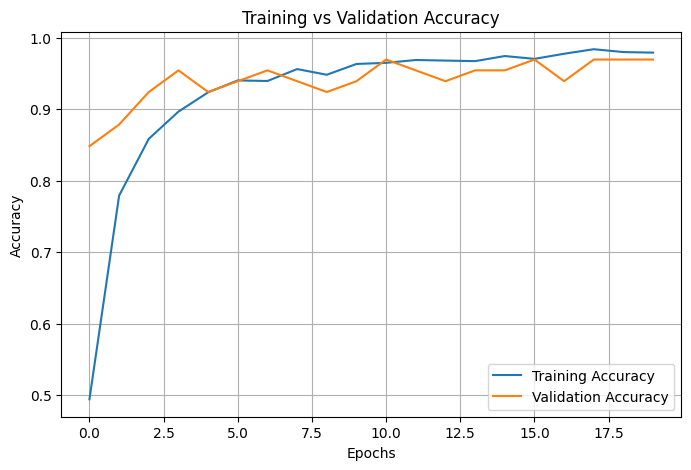

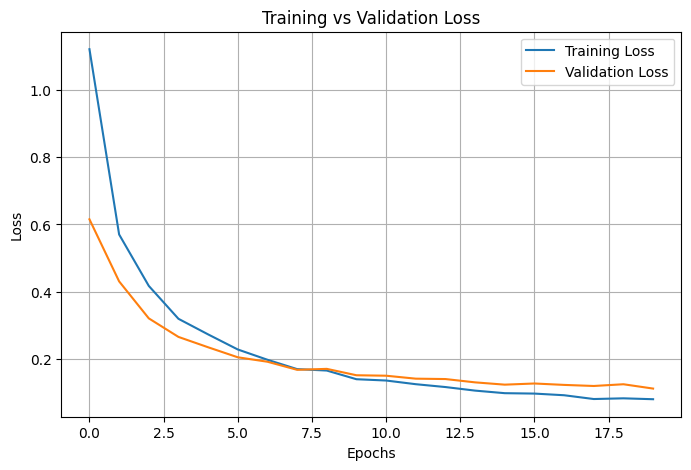

In [11]:
#Accuracy for frozen layers

import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


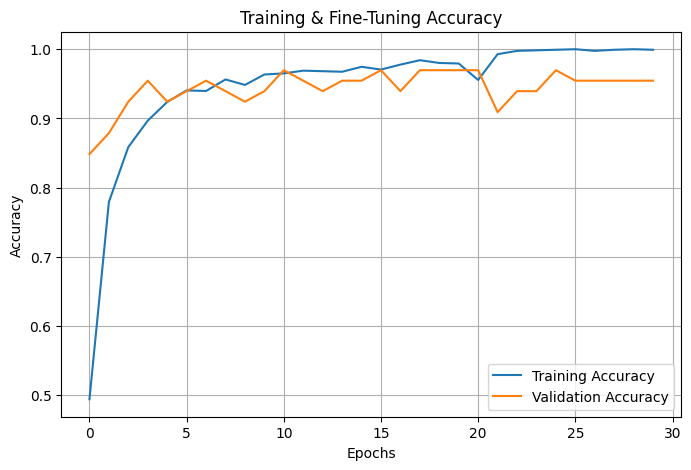

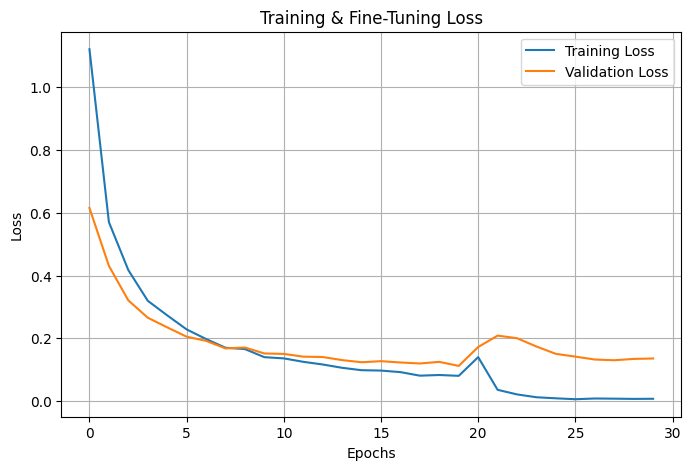

In [12]:
#Accuracy of both frozen and fine tuning

# Combine accuracy
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

# Combine loss
loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

epochs_range = range(len(acc))

# Accuracy graph
plt.figure(figsize=(8,5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Fine-Tuning Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss graph
plt.figure(figsize=(8,5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Fine-Tuning Loss")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)


3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 6s/step - accuracy: 0.9888 - loss: 0.0487
Test Accuracy: 0.9855072498321533


In [14]:
#Getting labels

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
# Predict classes for test data
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())
print(class_names)


3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step
['fully_cooked', 'raw', 'semi_cooked']


[[23  0  0]
 [ 0 23  0]
 [ 1  0 22]]


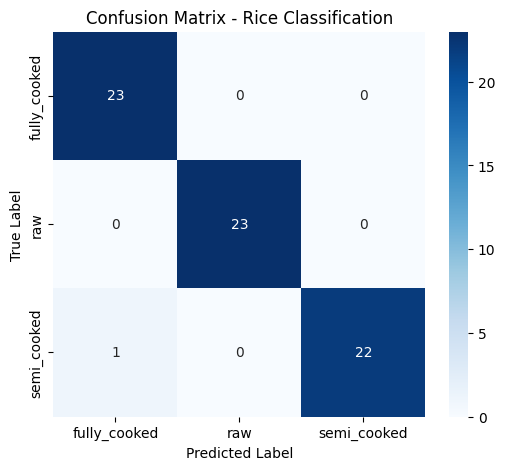

In [15]:
#Confusion matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Rice Classification")
plt.savefig("confusion_matrix_rice.png", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
#Classification report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)
print(report)


              precision    recall  f1-score   support

fully_cooked       0.96      1.00      0.98        23
         raw       1.00      1.00      1.00        23
 semi_cooked       1.00      0.96      0.98        23

    accuracy                           0.99        69
   macro avg       0.99      0.99      0.99        69
weighted avg       0.99      0.99      0.99        69



In [1]:
from tensorflow.keras.models import load_model

model = load_model("resnet_rice_model.h5")
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,029 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 2 (12.00 B)

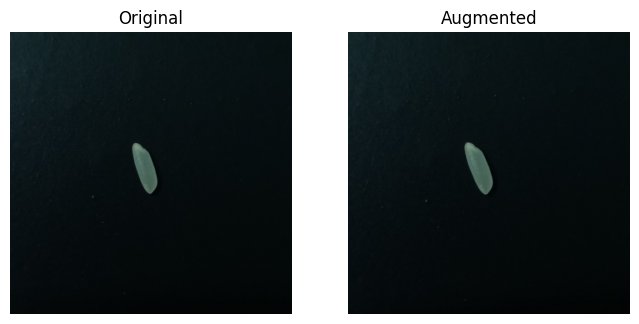

In [5]:
import os
import cv2
import matplotlib.pyplot as plt

# Define paths again (same as used earlier)
PROCESSED_DIR = os.path.join(os.getcwd(), "processed_dataset")
TRAIN_DIR = os.path.join(PROCESSED_DIR, "train")

CLASSES = ["raw", "semi_cooked", "fully_cooked"]

# Select one class and one image
cls = CLASSES[0]
class_dir = os.path.join(TRAIN_DIR, cls)

images = [f for f in os.listdir(class_dir)
          if f.lower().endswith((".jpg", ".jpeg", ".png"))
          and not f.startswith("aug_")]

orig_path = os.path.join(class_dir, images[0])
aug_path = os.path.join(class_dir, f"aug_{os.path.splitext(images[0])[0]}_0.jpg")

orig = cv2.imread(orig_path)
aug = cv2.imread(aug_path)

orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
aug  = cv2.cvtColor(aug, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(aug)
plt.title("Augmented")
plt.axis("off")

plt.show()


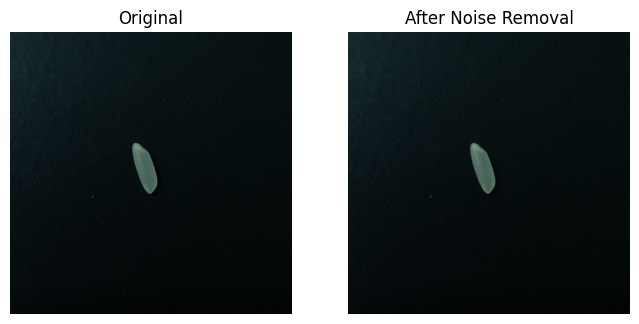

In [6]:
import cv2, os, matplotlib.pyplot as plt

orig_path = "dataset/raw/raw_1.jpg"
noiseless_path = "processed_noiseless/raw/raw_1.jpg"

orig = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
clean = cv2.cvtColor(cv2.imread(noiseless_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(orig); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(clean); plt.title("After Noise Removal"); plt.axis("off")
plt.show()
